## Calculating the Return of a Portfolio of Securities

Download data for a portfolio composed of 5 stocks. Do it for British Petroleum, Ford, Exxon, Lincoln, and Apple for the period ‘2002-1-1’ until today.

In [2]:
import numpy as np
import pandas as pd
from pandas_datareader import data as wb
import matplotlib.pyplot as plt
import yfinance as yf

In [5]:
tickers = ['BP', 'F', 'XOM', 'LNC', 'AAPL']
mydata = pd.DataFrame()
for t in tickers:
    mydata[t] = yf.download(t, start='2002-1-1')['Close']

C:\Users\Admin\AppData\Local\Temp\ipykernel_26448\2039454649.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  mydata[t] = yf.download(t, start='2002-1-1')['Close']
[*********************100%***********************]  1 of 1 completed
C:\Users\Admin\AppData\Local\Temp\ipykernel_26448\2039454649.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  mydata[t] = yf.download(t, start='2002-1-1')['Close']
[*********************100%***********************]  1 of 1 completed
C:\Users\Admin\AppData\Local\Temp\ipykernel_26448\2039454649.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  mydata[t] = yf.download(t, start='2002-1-1')['Close']
[*********************100%***********************]  1 of 1 completed
C:\Users\Admin\AppData\Local\Temp\ipykernel_26448\2039454649.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  mydata[t] = yf.download(t, start='2002-1-1'

In [6]:
mydata.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5996 entries, 2002-01-02 to 2025-10-29
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   BP      5996 non-null   float64
 1   F       5996 non-null   float64
 2   XOM     5996 non-null   float64
 3   LNC     5996 non-null   float64
 4   AAPL    5996 non-null   float64
dtypes: float64(5)
memory usage: 281.1 KB


In [7]:
mydata.head()

,BP,F,XOM,LNC,AAPL
Date,,,,,
2002-01-02,14.360587,7.119064,18.379332,24.925217,0.349734
2002-01-03,14.366827,7.342908,18.407179,25.327732,0.353937
2002-01-04,14.432320,7.435079,18.564981,25.766378,0.355589
2002-01-07,14.267041,7.241958,18.402538,25.544487,0.343731
2002-01-08,14.092399,7.268292,18.425741,25.684713,0.339377


In [8]:
mydata.tail()

,BP,F,XOM,LNC,AAPL
Date,,,,,
2025-10-23,35.000000,12.34,115.980003,39.349998,259.579987
2025-10-24,34.540001,13.84,115.389999,39.930000,262.820007
2025-10-27,34.770000,13.26,115.940002,40.320000,268.809998
2025-10-28,34.459999,13.13,115.029999,40.119999,269.000000
2025-10-29,35.200001,13.24,116.449997,40.029999,269.700012


### Normalization to 100:

$$
\frac {P_t}{P_0} * 100
$$

Normalize to a hundred and plot the data on a graph (you can apply the .loc() or the .iloc() method). 

In [9]:
mydata.iloc[0]

BP      14.360587
F        7.119064
XOM     18.379332
LNC     24.925217
AAPL     0.349734
Name: 2002-01-02 00:00:00, dtype: float64

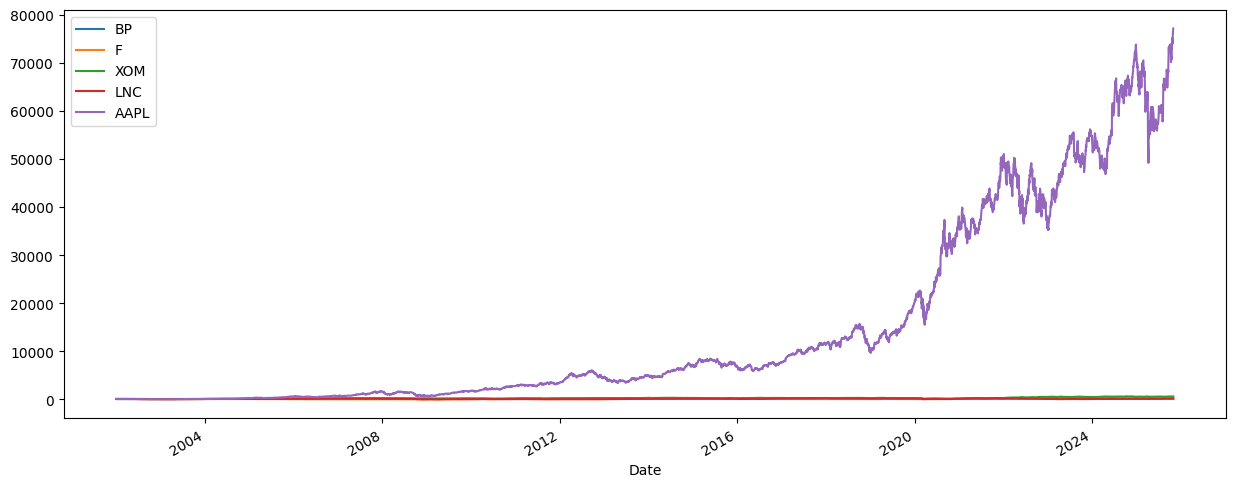

In [10]:
(mydata / mydata.iloc[0] * 100).plot(figsize = (15, 6));
plt.show()

How would you interpret the behavior of the stocks? Just by looking at the chart, would you be able to create a portfolio that provides a solid return on investment?

*****

### Calculating the Return of a Portfolio of Securities

Obtain the simple return of the securities in the portfolio and store the results in a new table.

In [11]:
returns = (mydata / mydata.shift(1)) - 1
returns.head()

,BP,F,XOM,LNC,AAPL
Date,,,,,
2002-01-02,NaN,NaN,NaN,NaN,NaN
2002-01-03,0.000435,0.031443,0.001515,0.016149,0.012017
2002-01-04,0.004559,0.012552,0.008573,0.017319,0.004667
2002-01-07,-0.011452,-0.025974,-0.008750,-0.008612,-0.033348
2002-01-08,-0.012241,0.003636,0.001261,0.005489,-0.012665


First, assume you would like to create an equally-weighted portfolio. Create the array, naming it “weights”.

In [12]:
weights = np.array([0.20, 0.20, 0.20, 0.20, 0.20])

Obtain the annual returns of each of the stocks and then calculate the dot product of these returns and the weights.

In [13]:
annual_returns = returns.mean() * 250
annual_returns

BP      0.081740
F       0.111891
XOM     0.110740
LNC     0.160585
AAPL    0.333604
dtype: float64

In [14]:
np.dot(annual_returns, weights)

np.float64(0.15971189562471075)

Transform the result into a percentage form. 

In [15]:
pfolio_1 = str(round(np.dot(annual_returns, weights), 5) * 100) + ' %'
pfolio_1

'15.970999999999998 %'

Is the return of this portfolio satisfactory?